<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/10_Rolling30_ARCH_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10 — ARCH-Family Robustness Models for Rolling-30-Day Historical Variance

This notebook evaluates the same ARCH-family specifications used in the primary daily-return experiment:

- GARCH(1,1)
- GJR-GARCH(1,1)
- EGARCH(1,1)

The alternative target is the **next-day 30-day rolling historical variance**:

\[
HV^2_{30,t+1}
=
\operatorname{Var}
\left(
r_{t-28},\ldots,r_t,r_{t+1}
\right)
\]

with sample variance (`ddof=1`).

## Why the GARCH forecast must be transformed

A standard GARCH model forecasts the conditional variance of the single unknown next return \(r_{t+1}\).  
That is not directly the same quantity as the 30-day rolling sample variance.

For each forecast date, 29 of the 30 returns entering the target are already known. Let:

- \(A\) = sum of the 29 known returns
- \(B\) = sum of their squared returns
- \(\mu\) = GARCH one-step-ahead conditional mean
- \(\sigma^2\) = GARCH one-step-ahead conditional variance
- \(n=30\)

Then:

\[
E[s^2_{30,t+1}]
=
\frac{
B + (\sigma^2+\mu^2)
-
\frac{
A^2+2A\mu+(\sigma^2+\mu^2)
}{30}
}{29}
\]

This notebook uses that analytical transformation so that ARCH and DL models are evaluated against the **same rolling-30 variance target**.

## Model-selection policy

The GARCH-family lag specifications are **not re-selected here**.

That is deliberate:

1. the underlying daily-return series is unchanged from the primary experiment;
2. the earlier lag diagnostics were performed on this same return process;
3. this is a robustness exercise for the **target definition**, so the ARCH specifications remain frozen.

No additional lag-selection statistical test is therefore required.

## 1. Imports and project paths

In [1]:
from google.colab import drive
from pathlib import Path

import sys
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from arch import arch_model
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "arch",
        ]
    )
    from arch import arch_model

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Quant Research"
)

DATA_PATH = (
    PROJECT_DIR
    / "data"
    / "model_ready"
    / "rolling30_historical_variance"
    / "crypto_daily_features_rolling30_v1.parquet"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
    / "rolling30_historical_variance"
    / "ARCH"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Input:")
print(DATA_PATH)

print("\nResults:")
print(RESULTS_DIR)

Mounted at /content/drive
Input:
/content/drive/MyDrive/Quant Research/data/model_ready/rolling30_historical_variance/crypto_daily_features_rolling30_v1.parquet

Results:
/content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/ARCH


## 2. Configuration

In [2]:
ASSETS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

TRAIN_END = pd.Timestamp(
    "2024-07-31",
    tz="UTC",
)

VALIDATION_START = pd.Timestamp(
    "2024-08-01",
    tz="UTC",
)

VALIDATION_END = pd.Timestamp(
    "2025-07-31",
    tz="UTC",
)

ROLLING_WINDOW = 30
KNOWN_RETURNS = ROLLING_WINDOW - 1

RETURN_SCALE = 100.0
EPSILON = 1e-12
MIN_TRAIN_OBS = 100

MODEL_SPECS = {
    "GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
    },
    "GJR-GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },
    "EGARCH(1,1)": {
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },
}

print("Models:")
for name in MODEL_SPECS:
    print(" -", name)

Models:
 - GARCH(1,1)
 - GJR-GARCH(1,1)
 - EGARCH(1,1)


## 3. Load and QC the rolling-30 dataset

The ARCH models continue to fit the **daily return series**.  
The new rolling-30 columns are used only to construct and evaluate the alternative target.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Rolling-30 dataset not found:\n"
        f"{DATA_PATH}"
    )

daily_df = pd.read_parquet(
    DATA_PATH
)

required_columns = [
    "symbol",
    "date",
    "daily_return",
    "rolling_30d_variance",
    "rolling30_var_mean_7d",
    "rolling30_var_mean_30d",
    "target_date",
    "target_rolling_30d_variance",
    "split",
]

missing_columns = [
    col
    for col in required_columns
    if col not in daily_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        f"{missing_columns}"
    )

daily_df["date"] = pd.to_datetime(
    daily_df["date"],
    utc=True,
    errors="raise",
)

daily_df["target_date"] = pd.to_datetime(
    daily_df["target_date"],
    utc=True,
    errors="coerce",
)

daily_df = (
    daily_df
    .loc[
        daily_df["symbol"].isin(
            ASSETS
        )
    ]
    .sort_values(
        [
            "symbol",
            "date",
        ]
    )
    .reset_index(drop=True)
)

if daily_df.duplicated(
    subset=[
        "symbol",
        "date",
    ]
).any():
    raise ValueError(
        "Duplicate symbol-date rows found."
    )

display(
    daily_df
    .groupby("symbol")
    .agg(
        first_date=(
            "date",
            "min",
        ),
        last_date=(
            "date",
            "max",
        ),
        rows=(
            "date",
            "size",
        ),
        non_null_returns=(
            "daily_return",
            "count",
        ),
    )
)

,first_date,last_date,rows,non_null_returns
symbol,,,,
BTCUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272,3271
ETHUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272,3271
SOLUSDT,2020-08-11 00:00:00+00:00,2026-08-01 00:00:00+00:00,2182,2181
XRPUSDT,2018-05-04 00:00:00+00:00,2026-08-01 00:00:00+00:00,3012,3011


## 4. Metric and rolling-variance transformation helpers

In [4]:
def qlike(
    y_true,
    y_pred,
    epsilon=EPSILON,
):
    y_true = np.maximum(
        np.asarray(
            y_true,
            dtype=float,
        ),
        epsilon,
    )

    y_pred = np.maximum(
        np.asarray(
            y_pred,
            dtype=float,
        ),
        epsilon,
    )

    ratio = (
        y_true
        / y_pred
    )

    return float(
        np.mean(
            ratio
            - np.log(ratio)
            - 1.0
        )
    )


def calculate_metrics(
    actual,
    predicted,
):
    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    actual = actual[valid]
    predicted = predicted[valid]

    if len(actual) == 0:
        raise ValueError(
            "No valid observations for metrics."
        )

    errors = (
        predicted
        - actual
    )

    return {
        "n_observations":
            int(len(actual)),

        "mae":
            float(
                np.mean(
                    np.abs(errors)
                )
            ),

        "rmse":
            float(
                np.sqrt(
                    np.mean(
                        errors ** 2
                    )
                )
            ),

        "qlike":
            qlike(
                actual,
                predicted,
            ),
    }


def expected_rolling_sample_variance(
    known_returns,
    forecast_mean,
    forecast_variance,
):
    known_returns = np.asarray(
        known_returns,
        dtype=float,
    )

    if len(known_returns) != KNOWN_RETURNS:
        raise ValueError(
            f"Expected {KNOWN_RETURNS} "
            "known returns, got "
            f"{len(known_returns)}."
        )

    if not np.isfinite(
        known_returns
    ).all():
        raise ValueError(
            "Known-return window "
            "contains non-finite values."
        )

    forecast_mean = float(
        forecast_mean
    )

    forecast_variance = float(
        forecast_variance
    )

    if (
        not np.isfinite(
            forecast_mean
        )
        or not np.isfinite(
            forecast_variance
        )
    ):
        return np.nan

    forecast_variance = max(
        forecast_variance,
        0.0,
    )

    sum_known = float(
        known_returns.sum()
    )

    sumsq_known = float(
        np.square(
            known_returns
        ).sum()
    )

    next_second_moment = (
        forecast_variance
        + forecast_mean ** 2
    )

    expected_total_square = (
        sumsq_known
        + next_second_moment
    )

    expected_square_of_sum = (
        sum_known ** 2
        + 2.0
        * sum_known
        * forecast_mean
        + next_second_moment
    )

    expected_sample_variance = (
        expected_total_square
        - (
            expected_square_of_sum
            / ROLLING_WINDOW
        )
    ) / (
        ROLLING_WINDOW - 1
    )

    return max(
        float(
            expected_sample_variance
        ),
        EPSILON,
    )


def get_known_29_returns(
    return_series,
    target_date,
):
    end_date = (
        target_date
        - pd.Timedelta(days=1)
    )

    start_date = (
        target_date
        - pd.Timedelta(
            days=KNOWN_RETURNS
        )
    )

    known = (
        return_series.loc[
            start_date:
            end_date
        ]
        .dropna()
    )

    if len(known) != KNOWN_RETURNS:
        return None

    if (
        known.index[-1]
        - known.index[0]
        != pd.Timedelta(
            days=KNOWN_RETURNS - 1
        )
    ):
        return None

    if not (
        known.index.to_series()
        .diff()
        .dropna()
        .eq(
            pd.Timedelta(days=1)
        )
        .all()
    ):
        return None

    return known.to_numpy(
        dtype=float
    )

## 5. Transformation identity QC

Before fitting any ARCH model, this cell validates the analytical rolling-variance formula.

If the unknown next-day return is replaced by the **actual observed next-day return** and its forecast uncertainty is set to zero, the analytical formula must exactly reproduce the saved 30-day rolling sample variance.

This is an indexing/formula QC, not a forecasting result.

In [5]:
identity_rows = []

for asset in ASSETS:

    asset_df = (
        daily_df.loc[
            daily_df[
                "symbol"
            ].eq(asset)
        ]
        .sort_values("date")
        .copy()
    )

    returns = (
        asset_df
        .set_index("date")[
            "daily_return"
        ]
        .astype(float)
    )

    validation_targets = (
        asset_df.loc[
            asset_df[
                "split"
            ].eq("validation")
        ]
        .copy()
    )

    errors = []

    for _, row in (
        validation_targets.iterrows()
    ):

        target_date = (
            row["target_date"]
        )

        known_returns = (
            get_known_29_returns(
                returns,
                target_date,
            )
        )

        if known_returns is None:
            continue

        if (
            target_date
            not in returns.index
        ):
            continue

        actual_next_return = float(
            returns.loc[
                target_date
            ]
        )

        reconstructed = (
            expected_rolling_sample_variance(
                known_returns=
                    known_returns,
                forecast_mean=
                    actual_next_return,
                forecast_variance=
                    0.0,
            )
        )

        saved_target = float(
            row[
                "target_rolling_30d_variance"
            ]
        )

        errors.append(
            abs(
                reconstructed
                - saved_target
            )
        )

    if not errors:
        raise ValueError(
            f"No identity-QC observations "
            f"for {asset}."
        )

    identity_rows.append({
        "asset":
            asset,

        "observations":
            len(errors),

        "max_absolute_difference":
            float(
                np.max(errors)
            ),

        "mean_absolute_difference":
            float(
                np.mean(errors)
            ),
    })


identity_qc_df = pd.DataFrame(
    identity_rows
)

display(
    identity_qc_df
)

if (
    identity_qc_df[
        "max_absolute_difference"
    ].max()
    > 1e-10
):
    raise AssertionError(
        "Rolling-variance analytical "
        "transformation failed QC."
    )

print(
    "Analytical rolling-variance "
    "transformation passed QC."
)

,asset,observations,max_absolute_difference,mean_absolute_difference
0,BTCUSDT,365,1.019150e-17,9.360452e-18
1,ETHUSDT,365,2.125036e-17,1.939148e-17
2,SOLUSDT,365,1.561251e-17,1.226663e-17
3,XRPUSDT,365,1.734723e-17,1.041072e-17


Analytical rolling-variance transformation passed QC.


## 6. Fit fixed-parameter ARCH models and forecast validation

For every asset/model combination:

1. parameters are estimated using returns through `2024-07-31`;
2. those parameters remain fixed;
3. realized validation returns update the conditional state sequentially;
4. one-step-ahead conditional mean and variance are generated;
5. the single-return forecast is transformed into the expected next 30-day rolling sample variance.

The test set is not loaded or evaluated here.

In [6]:
def fit_and_forecast_validation(
    asset,
    model_name,
    spec,
):
    asset_df = (
        daily_df.loc[
            daily_df[
                "symbol"
            ].eq(asset)
        ]
        .sort_values("date")
        .copy()
    )

    return_series = (
        asset_df
        .set_index("date")[
            "daily_return"
        ]
        .astype(float)
    )

    train_returns = (
        return_series.loc[
            return_series.index
            <= TRAIN_END
        ]
        .dropna()
    )

    validation_returns = (
        return_series.loc[
            (
                return_series.index
                >= VALIDATION_START
            )
            & (
                return_series.index
                <= VALIDATION_END
            )
        ]
        .dropna()
    )

    if (
        len(train_returns)
        < MIN_TRAIN_OBS
    ):
        raise ValueError(
            f"Insufficient training data "
            f"for {asset}."
        )

    if len(validation_returns) != 365:
        raise ValueError(
            f"{asset} validation returns "
            f"have {len(validation_returns)} "
            "observations instead of 365."
        )

    scaled_train = (
        train_returns
        * RETURN_SCALE
    )

    history_returns = (
        pd.concat(
            [
                train_returns,
                validation_returns,
            ]
        )
        .sort_index()
    )

    scaled_history = (
        history_returns
        * RETURN_SCALE
    )

    train_model = arch_model(
        scaled_train,
        mean="Constant",
        dist="t",
        rescale=False,
        **spec,
    )

    fit = train_model.fit(
        disp="off",
        show_warning=False,
        update_freq=0,
    )

    full_model = arch_model(
        scaled_history,
        mean="Constant",
        dist="t",
        rescale=False,
        **spec,
    )

    fixed = full_model.fix(
        fit.params
    )

    forecasts = fixed.forecast(
        horizon=1,
        start=(
            len(train_returns)
            - 1
        ),
        align="target",
        reindex=True,
    )

    mean_scaled = (
        forecasts
        .mean["h.1"]
        .reindex(
            validation_returns.index
        )
    )

    variance_scaled = (
        forecasts
        .variance["h.1"]
        .reindex(
            validation_returns.index
        )
    )

    forecast_mean = (
        mean_scaled
        / RETURN_SCALE
    )

    forecast_variance = (
        variance_scaled
        / (
            RETURN_SCALE ** 2
        )
    )

    target_rows = (
        asset_df.loc[
            asset_df[
                "split"
            ].eq("validation")
        ]
        .set_index(
            "target_date"
        )
        .sort_index()
    )

    records = []

    for target_date in (
        validation_returns.index
    ):

        if (
            target_date
            not in target_rows.index
        ):
            continue

        known_returns = (
            get_known_29_returns(
                return_series,
                target_date,
            )
        )

        if known_returns is None:
            continue

        mu = (
            forecast_mean.loc[
                target_date
            ]
        )

        sigma2 = (
            forecast_variance.loc[
                target_date
            ]
        )

        if (
            pd.isna(mu)
            or pd.isna(sigma2)
        ):
            continue

        predicted_rolling_variance = (
            expected_rolling_sample_variance(
                known_returns=
                    known_returns,
                forecast_mean=
                    mu,
                forecast_variance=
                    sigma2,
            )
        )

        target_row = (
            target_rows.loc[
                target_date
            ]
        )

        actual_rolling_variance = float(
            target_row[
                "target_rolling_30d_variance"
            ]
        )

        records.append({
            "asset":
                asset,

            "model":
                model_name,

            "target_date":
                target_date,

            "actual_rolling30_variance":
                actual_rolling_variance,

            "forecast_rolling30_variance":
                predicted_rolling_variance,

            "forecast_next_return_mean":
                float(mu),

            "forecast_next_return_variance":
                float(sigma2),
        })

    predictions_df = (
        pd.DataFrame(
            records
        )
    )

    if len(predictions_df) != 365:
        raise ValueError(
            f"{asset} {model_name}: "
            f"expected 365 forecasts, got "
            f"{len(predictions_df)}."
        )

    metrics = calculate_metrics(
        predictions_df[
            "actual_rolling30_variance"
        ],
        predictions_df[
            "forecast_rolling30_variance"
        ],
    )

    metric_row = {
        "asset":
            asset,

        "model":
            model_name,

        "evaluation_period":
            "validation",

        "n_train":
            int(
                len(train_returns)
            ),

        "converged":
            bool(
                fit.convergence_flag
                == 0
            ),

        "loglikelihood":
            float(
                fit.loglikelihood
            ),

        "aic":
            float(
                fit.aic
            ),

        "bic":
            float(
                fit.bic
            ),

        **metrics,
    }

    return (
        predictions_df,
        metric_row,
    )

In [7]:
arch_prediction_frames = []
arch_metric_rows = []

for asset in ASSETS:

    print(
        "\n"
        + "=" * 72
    )

    print(asset)

    print(
        "=" * 72
    )

    for (
        model_name,
        spec,
    ) in MODEL_SPECS.items():

        print(
            f"Fitting {model_name}..."
        )

        (
            predictions_df,
            metric_row,
        ) = fit_and_forecast_validation(
            asset=asset,
            model_name=model_name,
            spec=spec,
        )

        arch_prediction_frames.append(
            predictions_df
        )

        arch_metric_rows.append(
            metric_row
        )

        print(
            f"  QLIKE="
            f"{metric_row['qlike']:.6f} | "
            f"MAE="
            f"{metric_row['mae']:.8f} | "
            f"RMSE="
            f"{metric_row['rmse']:.8f} | "
            f"Converged="
            f"{metric_row['converged']}"
        )


arch_predictions_df = (
    pd.concat(
        arch_prediction_frames,
        ignore_index=True,
    )
)

arch_metrics_df = (
    pd.DataFrame(
        arch_metric_rows
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

display(
    arch_metrics_df.style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
        "loglikelihood":
            "{:.2f}",
        "aic":
            "{:.2f}",
        "bic":
            "{:.2f}",
    })
)


BTCUSDT
Fitting GARCH(1,1)...
  QLIKE=0.002567 | MAE=0.00002768 | RMSE=0.00004514 | Converged=True
Fitting GJR-GARCH(1,1)...
  QLIKE=0.002584 | MAE=0.00002768 | RMSE=0.00004526 | Converged=True
Fitting EGARCH(1,1)...
  QLIKE=0.002765 | MAE=0.00003273 | RMSE=0.00004778 | Converged=True

ETHUSDT
Fitting GARCH(1,1)...
  QLIKE=0.003161 | MAE=0.00006762 | RMSE=0.00011763 | Converged=True
Fitting GJR-GARCH(1,1)...
  QLIKE=0.003170 | MAE=0.00006733 | RMSE=0.00011765 | Converged=True
Fitting EGARCH(1,1)...
  QLIKE=0.003205 | MAE=0.00006784 | RMSE=0.00011735 | Converged=True

SOLUSDT
Fitting GARCH(1,1)...
  QLIKE=0.002666 | MAE=0.00008906 | RMSE=0.00016248 | Converged=True
Fitting GJR-GARCH(1,1)...
  QLIKE=0.002666 | MAE=0.00008902 | RMSE=0.00016235 | Converged=True
Fitting EGARCH(1,1)...
  QLIKE=0.002669 | MAE=0.00008779 | RMSE=0.00016132 | Converged=True

XRPUSDT
Fitting GARCH(1,1)...
  QLIKE=0.005047 | MAE=0.00011875 | RMSE=0.00024562 | Converged=True
Fitting GJR-GARCH(1,1)...
  QLIKE=0.005

,asset,model,evaluation_period,n_train,converged,loglikelihood,aic,bic,n_observations,mae,rmse,qlike
0,BTCUSDT,"GARCH(1,1)",validation,2540,True,-6516.45,13042.90,13072.10,365,0.00002768,0.00004514,0.002567
1,BTCUSDT,"GJR-GARCH(1,1)",validation,2540,True,-6515.92,13043.83,13078.87,365,0.00002768,0.00004526,0.002584
2,BTCUSDT,"EGARCH(1,1)",validation,2540,True,-6502.97,13017.95,13052.99,365,0.00003273,0.00004778,0.002765
3,ETHUSDT,"GARCH(1,1)",validation,2540,True,-7177.07,14364.14,14393.34,365,0.00006762,0.00011763,0.003161
4,ETHUSDT,"GJR-GARCH(1,1)",validation,2540,True,-7176.91,14365.83,14400.87,365,0.00006733,0.00011765,0.003170
5,ETHUSDT,"EGARCH(1,1)",validation,2540,True,-7163.80,14339.60,14374.64,365,0.00006784,0.00011735,0.003205
6,SOLUSDT,"GARCH(1,1)",validation,1450,True,-4615.79,9241.59,9267.98,365,0.00008906,0.00016248,0.002666
7,SOLUSDT,"GJR-GARCH(1,1)",validation,1450,True,-4615.77,9243.54,9275.21,365,0.00008902,0.00016235,0.002666
8,SOLUSDT,"EGARCH(1,1)",validation,1450,True,-4618.56,9249.12,9280.80,365,0.00008779,0.00016132,0.002669
9,XRPUSDT,"EGARCH(1,1)",validation,2280,True,-6355.04,12722.08,12756.47,365,0.00011230,0.00023702,0.004998


## 7. Rolling-variance baselines

These baselines are known at forecast origin `t` and predict the target at `t+1`:

- **Persistence:** current 30-day rolling variance
- **7-Day Mean Rolling Variance:** trailing 7-day mean of the rolling-30 variance state
- **30-Day Mean Rolling Variance:** trailing 30-day mean of the rolling-30 variance state

Because adjacent 30-day rolling windows share 29 observations, persistence is expected to be substantially stronger here than for the squared-daily-return target.

In [8]:
baseline_metric_rows = []
baseline_prediction_frames = []

BASELINE_COLUMNS = {
    "Rolling30 Persistence":
        "rolling_30d_variance",

    "7-Day Mean Rolling30 Variance":
        "rolling30_var_mean_7d",

    "30-Day Mean Rolling30 Variance":
        "rolling30_var_mean_30d",
}

for asset in ASSETS:

    validation_rows = (
        daily_df.loc[
            daily_df[
                "symbol"
            ].eq(asset)
            & daily_df[
                "split"
            ].eq("validation")
        ]
        .sort_values(
            "target_date"
        )
        .copy()
    )

    if len(validation_rows) != 365:
        raise ValueError(
            f"{asset}: expected 365 "
            "validation target rows, got "
            f"{len(validation_rows)}."
        )

    actual = (
        validation_rows[
            "target_rolling_30d_variance"
        ]
        .to_numpy(
            dtype=float
        )
    )

    for (
        baseline_name,
        predictor_column,
    ) in BASELINE_COLUMNS.items():

        predicted = (
            validation_rows[
                predictor_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        metrics = calculate_metrics(
            actual,
            predicted,
        )

        baseline_metric_rows.append({
            "asset":
                asset,

            "model":
                baseline_name,

            "evaluation_period":
                "validation",

            "n_train":
                np.nan,

            "converged":
                np.nan,

            "loglikelihood":
                np.nan,

            "aic":
                np.nan,

            "bic":
                np.nan,

            **metrics,
        })

        baseline_prediction_frames.append(
            pd.DataFrame({
                "asset":
                    asset,

                "model":
                    baseline_name,

                "target_date":
                    validation_rows[
                        "target_date"
                    ].to_numpy(),

                "actual_rolling30_variance":
                    actual,

                "forecast_rolling30_variance":
                    predicted,
            })
        )


baseline_metrics_df = (
    pd.DataFrame(
        baseline_metric_rows
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

baseline_predictions_df = (
    pd.concat(
        baseline_prediction_frames,
        ignore_index=True,
    )
)

display(
    baseline_metrics_df.style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
    })
)

,asset,model,evaluation_period,n_train,converged,loglikelihood,aic,bic,n_observations,mae,rmse,qlike
0,BTCUSDT,Rolling30 Persistence,validation,nan,nan,nan,nan,nan,365,0.00003273,0.00006389,0.004915
1,BTCUSDT,7-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00007671,0.00012011,0.015032
2,BTCUSDT,30-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00019887,0.00026192,0.066439
3,ETHUSDT,Rolling30 Persistence,validation,nan,nan,nan,nan,nan,365,0.00007116,0.00015748,0.005222
4,ETHUSDT,7-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00016452,0.00026492,0.015547
5,ETHUSDT,30-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00036178,0.00049989,0.058521
6,SOLUSDT,Rolling30 Persistence,validation,nan,nan,nan,nan,nan,365,0.00009710,0.00022837,0.004887
7,SOLUSDT,7-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00023488,0.00046713,0.016143
8,SOLUSDT,30-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00057793,0.00092934,0.053471
9,XRPUSDT,Rolling30 Persistence,validation,nan,nan,nan,nan,nan,365,0.00013483,0.00033969,0.009537


## 8. Combined validation comparison and best model by asset

In [9]:
combined_metrics_df = (
    pd.concat(
        [
            arch_metrics_df,
            baseline_metrics_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

combined_metrics_df[
    "qlike_rank"
] = (
    combined_metrics_df
    .groupby("asset")[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

best_model_by_asset_df = (
    combined_metrics_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False,
    )
    .first()
)

print(
    "All ARCH + baseline "
    "validation results:"
)

display(
    combined_metrics_df.style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
    })
)

print(
    "\nBest model by "
    "validation QLIKE:"
)

display(
    best_model_by_asset_df[
        [
            "asset",
            "model",
            "mae",
            "rmse",
            "qlike",
        ]
    ].style.format({
        "mae":
            "{:.8f}",
        "rmse":
            "{:.8f}",
        "qlike":
            "{:.6f}",
    })
)

All ARCH + baseline validation results:


,asset,model,evaluation_period,n_train,converged,loglikelihood,aic,bic,n_observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,"GARCH(1,1)",validation,2540.000000,1.000000,-6516.449481,13042.898963,13072.098559,365,0.00002768,0.00004514,0.002567,1
1,BTCUSDT,"GJR-GARCH(1,1)",validation,2540.000000,1.000000,-6515.915102,13043.830205,13078.869721,365,0.00002768,0.00004526,0.002584,2
2,BTCUSDT,"EGARCH(1,1)",validation,2540.000000,1.000000,-6502.973937,13017.947874,13052.987390,365,0.00003273,0.00004778,0.002765,3
3,BTCUSDT,Rolling30 Persistence,validation,nan,nan,nan,nan,nan,365,0.00003273,0.00006389,0.004915,4
4,BTCUSDT,7-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00007671,0.00012011,0.015032,5
5,BTCUSDT,30-Day Mean Rolling30 Variance,validation,nan,nan,nan,nan,nan,365,0.00019887,0.00026192,0.066439,6
6,ETHUSDT,"GARCH(1,1)",validation,2540.000000,1.000000,-7177.067714,14364.135427,14393.335024,365,0.00006762,0.00011763,0.003161,1
7,ETHUSDT,"GJR-GARCH(1,1)",validation,2540.000000,1.000000,-7176.912914,14365.825829,14400.865345,365,0.00006733,0.00011765,0.003170,2
8,ETHUSDT,"EGARCH(1,1)",validation,2540.000000,1.000000,-7163.799570,14339.599140,14374.638656,365,0.00006784,0.00011735,0.003205,3
9,ETHUSDT,Rolling30 Persistence,validation,nan,nan,nan,nan,nan,365,0.00007116,0.00015748,0.005222,4



Best model by validation QLIKE:


,asset,model,mae,rmse,qlike
0,BTCUSDT,"GARCH(1,1)",0.00002768,0.00004514,0.002567
1,ETHUSDT,"GARCH(1,1)",0.00006762,0.00011763,0.003161
2,SOLUSDT,"GARCH(1,1)",0.00008906,0.00016248,0.002666
3,XRPUSDT,"EGARCH(1,1)",0.00011230,0.00023702,0.004998


## 9. Save all validation outputs

In [10]:
ARCH_METRICS_PATH = (
    RESULTS_DIR
    / "rolling30_arch_validation_metrics.csv"
)

ARCH_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "rolling30_arch_validation_predictions.parquet"
)

BASELINE_METRICS_PATH = (
    RESULTS_DIR
    / "rolling30_baseline_validation_metrics.csv"
)

BASELINE_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "rolling30_baseline_validation_predictions.parquet"
)

COMBINED_METRICS_PATH = (
    RESULTS_DIR
    / "rolling30_arch_and_baseline_validation_metrics.csv"
)

BEST_MODELS_PATH = (
    RESULTS_DIR
    / "rolling30_best_arch_or_baseline_by_asset.csv"
)

arch_metrics_df.to_csv(
    ARCH_METRICS_PATH,
    index=False,
)

arch_predictions_df.to_parquet(
    ARCH_PREDICTIONS_PATH,
    index=False,
)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

baseline_predictions_df.to_parquet(
    BASELINE_PREDICTIONS_PATH,
    index=False,
)

combined_metrics_df.to_csv(
    COMBINED_METRICS_PATH,
    index=False,
)

best_model_by_asset_df.to_csv(
    BEST_MODELS_PATH,
    index=False,
)

print("Saved:")
for path in [
    ARCH_METRICS_PATH,
    ARCH_PREDICTIONS_PATH,
    BASELINE_METRICS_PATH,
    BASELINE_PREDICTIONS_PATH,
    COMBINED_METRICS_PATH,
    BEST_MODELS_PATH,
]:
    print(" -", path)

Saved:
 - /content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/ARCH/rolling30_arch_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/ARCH/rolling30_arch_validation_predictions.parquet
 - /content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/ARCH/rolling30_baseline_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/ARCH/rolling30_baseline_validation_predictions.parquet
 - /content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/ARCH/rolling30_arch_and_baseline_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/results/rolling30_historical_variance/ARCH/rolling30_best_arch_or_baseline_by_asset.csv


## 10. Plot actual rolling-30 volatility vs model forecasts

The model is evaluated on variance scale.  
For visualization only, both actual and predicted variance are square-rooted back to the rolling standard-deviation scale.

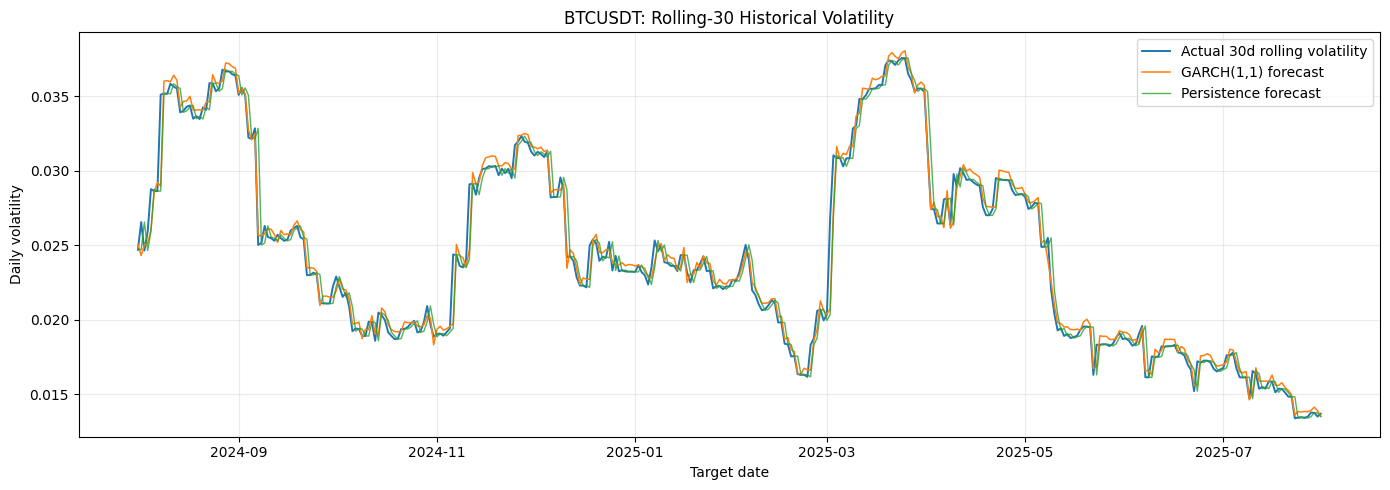

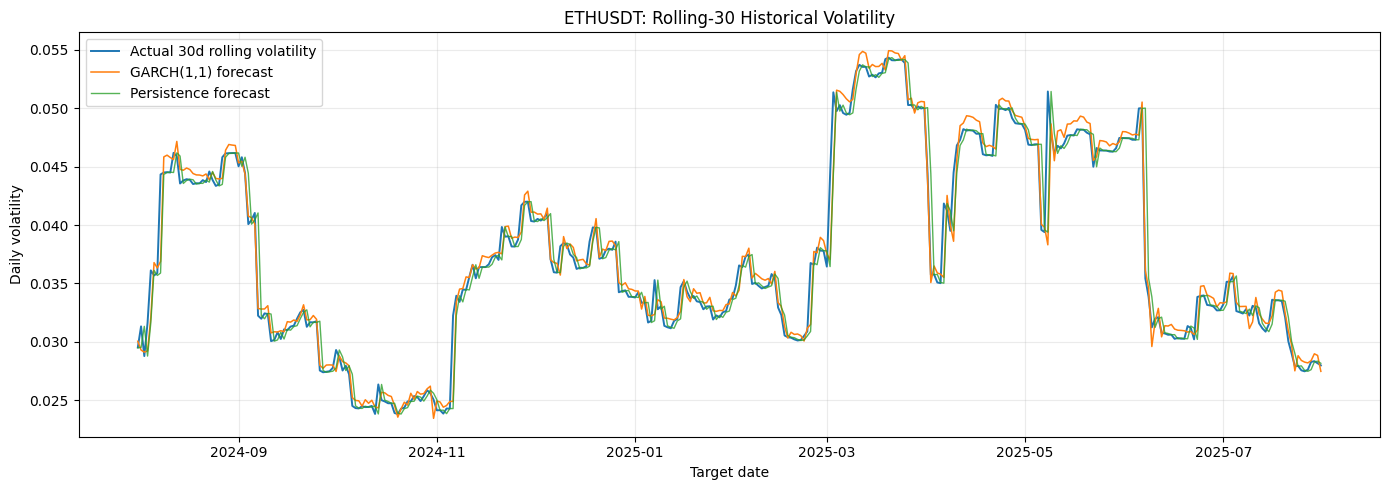

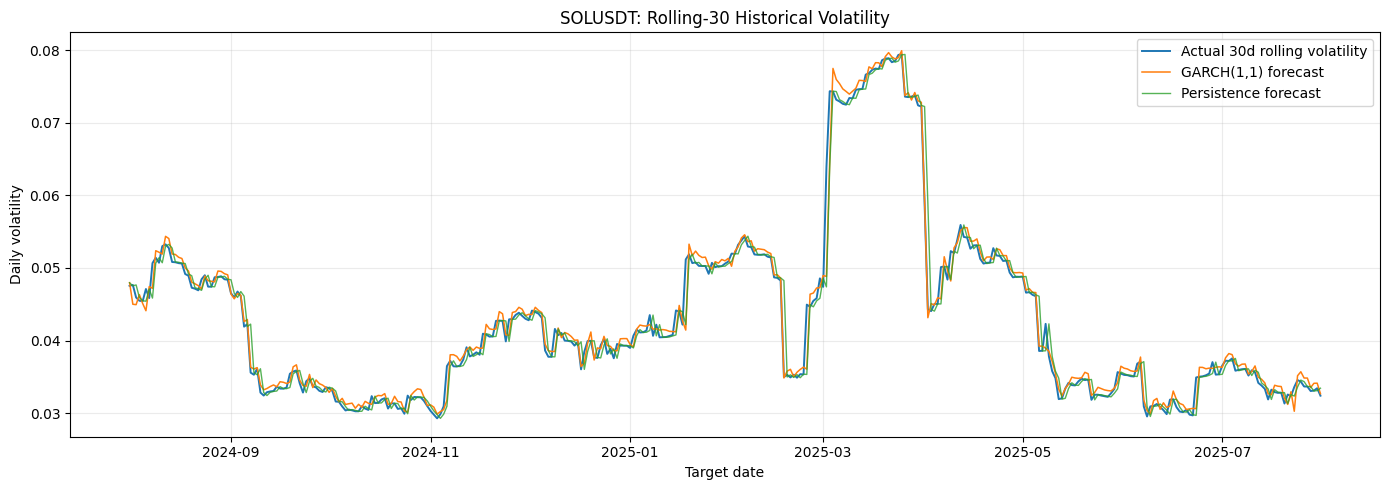

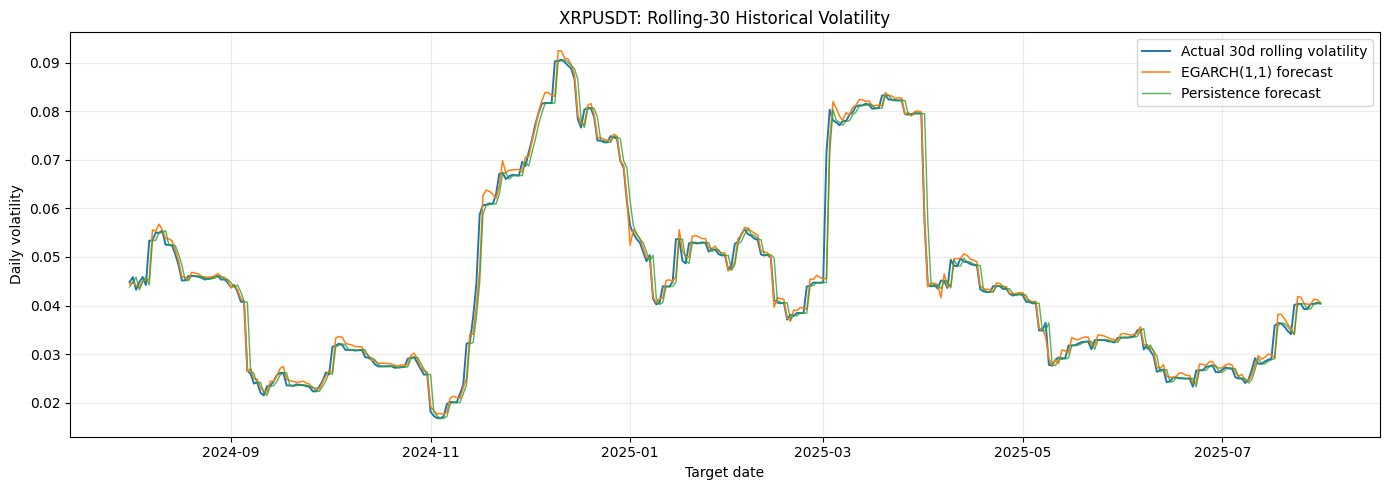

In [11]:
best_arch_only_df = (
    arch_metrics_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False,
    )
    .first()
)

for asset in ASSETS:

    best_arch_model = (
        best_arch_only_df.loc[
            best_arch_only_df[
                "asset"
            ].eq(asset),
            "model",
        ]
        .iloc[0]
    )

    arch_plot_df = (
        arch_predictions_df.loc[
            arch_predictions_df[
                "asset"
            ].eq(asset)
            & arch_predictions_df[
                "model"
            ].eq(
                best_arch_model
            )
        ]
        .sort_values(
            "target_date"
        )
        .copy()
    )

    baseline_plot_df = (
        baseline_predictions_df.loc[
            baseline_predictions_df[
                "asset"
            ].eq(asset)
            & baseline_predictions_df[
                "model"
            ].eq(
                "Rolling30 Persistence"
            )
        ]
        .sort_values(
            "target_date"
        )
        .copy()
    )

    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        arch_plot_df[
            "target_date"
        ],
        np.sqrt(
            arch_plot_df[
                "actual_rolling30_variance"
            ]
        ),
        label="Actual 30d rolling volatility",
        linewidth=1.4,
    )

    plt.plot(
        arch_plot_df[
            "target_date"
        ],
        np.sqrt(
            arch_plot_df[
                "forecast_rolling30_variance"
            ]
        ),
        label=(
            f"{best_arch_model} forecast"
        ),
        linewidth=1.1,
    )

    plt.plot(
        baseline_plot_df[
            "target_date"
        ],
        np.sqrt(
            baseline_plot_df[
                "forecast_rolling30_variance"
            ]
        ),
        label="Persistence forecast",
        linewidth=1.0,
        alpha=0.8,
    )

    plt.title(
        f"{asset}: Rolling-30 Historical Volatility"
    )

    plt.xlabel("Target date")
    plt.ylabel("Daily volatility")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 11. Final QC checks

In [12]:
# Every ARCH model should have exactly 365 validation forecasts.
arch_counts = (
    arch_predictions_df
    .groupby(
        [
            "asset",
            "model",
        ]
    )
    .size()
)

assert (
    arch_counts
    == 365
).all()

# Every baseline should also have exactly 365 observations.
baseline_counts = (
    baseline_predictions_df
    .groupby(
        [
            "asset",
            "model",
        ]
    )
    .size()
)

assert (
    baseline_counts
    == 365
).all()

# QLIKE should be non-negative apart from negligible numerical noise.
assert (
    combined_metrics_df[
        "qlike"
    ]
    >= -1e-12
).all()

# All variance forecasts used for evaluation must be positive.
assert (
    arch_predictions_df[
        "forecast_rolling30_variance"
    ]
    > 0
).all()

assert (
    baseline_predictions_df[
        "forecast_rolling30_variance"
    ]
    > 0
).all()

# Validation dates must match the canonical period.
assert (
    arch_predictions_df[
        "target_date"
    ].min()
    == VALIDATION_START
)

assert (
    arch_predictions_df[
        "target_date"
    ].max()
    == VALIDATION_END
)

print(
    "All ARCH robustness "
    "validation QC checks passed."
)

All ARCH robustness validation QC checks passed.


## Interpretation

The main files for the next stage are:

```text
results/
└── rolling30_historical_variance/
    └── ARCH/
        ├── rolling30_arch_validation_metrics.csv
        ├── rolling30_arch_validation_predictions.parquet
        ├── rolling30_baseline_validation_metrics.csv
        ├── rolling30_baseline_validation_predictions.parquet
        ├── rolling30_arch_and_baseline_validation_metrics.csv
        └── rolling30_best_arch_or_baseline_by_asset.csv
```

The test set remains untouched.

The next robustness step is to retrain the already-selected DL specifications against `log_rolling_30d_variance` and compare their validation results against these ARCH/baseline forecasts.